In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv(r"C:\Users\smrut_koi9iy6\Downloads\seasonal_agriculture_performance_dataset.csv")

# Impute missing values (Rainfall_mm, Soil_Moisture_pct, Yield_Tonnes_Ha) using the median of their respective season
cols_to_fill = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']
for col in cols_to_fill:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    4000 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              4000 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

,Season,Yield_Tonnes_Ha,Production_Tonnes,Total_Cost_INR,Revenue_INR,Profit_INR
0,Kharif,5.63,46.31,531804.41,710719.06,178914.65
1,Rabi,5.04,41.49,513836.58,601526.05,87689.47
2,Zaid,4.64,38.89,543976.73,519171.90,-24804.82


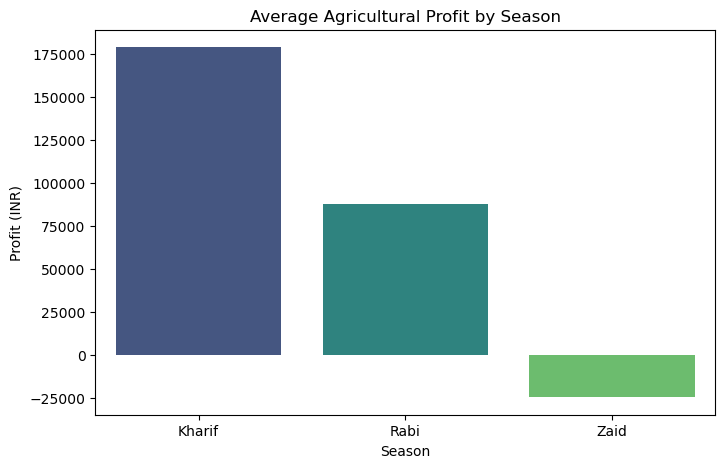

In [10]:
# Group by season to find average yield, production, and profitability
seasonal_performance = df.groupby('Season')[
    ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR']
].mean().reset_index()

# Display the performance summary
display(seasonal_performance.round(2))

# Visualize Average Profit per Season
plt.figure(figsize=(8, 5))
sns.barplot(data=seasonal_performance, x='Season', y='Profit_INR', hue='Season', palette='viridis', legend=False)
plt.title('Average Agricultural Profit by Season')
plt.ylabel('Profit (INR)')
plt.show()

,Season,Rainfall_mm,Avg_Temperature_C,Water_Used_m3,Water_Efficiency_t_per_1000m3,Fertilizer_kg_ha
0,Kharif,852.11,28.45,6102.20,5.89,187.08
1,Rabi,435.94,23.49,5846.99,5.19,185.41
2,Zaid,299.12,31.04,6419.89,4.41,184.64


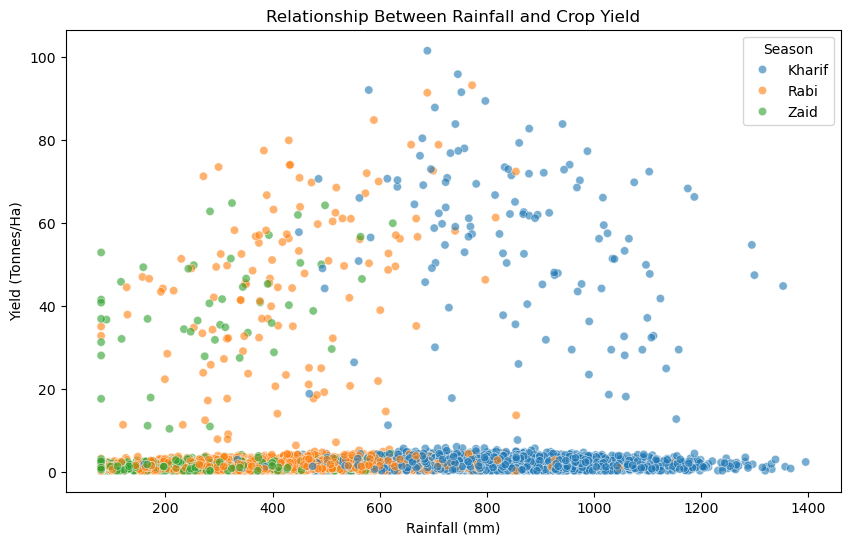

In [11]:
# Analyze resource usage across seasons
resource_usage = df.groupby('Season')[
    ['Rainfall_mm', 'Avg_Temperature_C', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Fertilizer_kg_ha']
].mean().reset_index()

display(resource_usage.round(2))

# Scatter plot: Relationship between rainfall and yield across seasons
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', alpha=0.6)
plt.title('Relationship Between Rainfall and Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

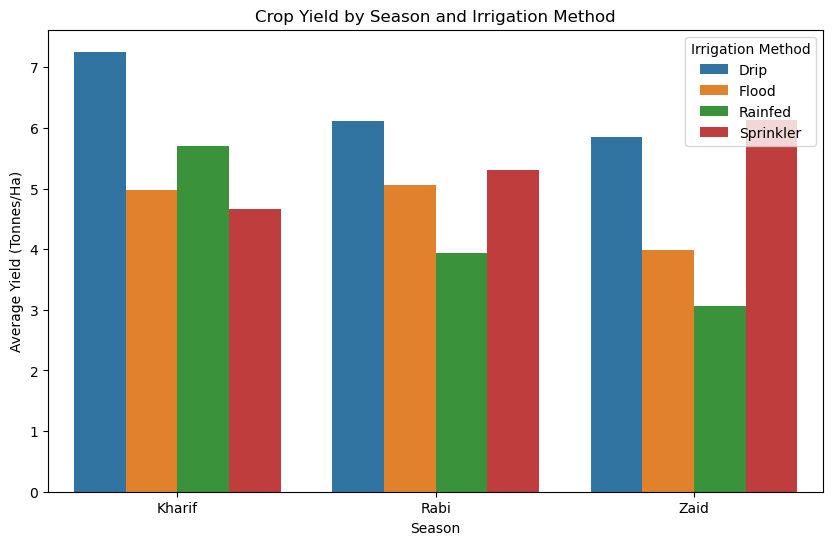

In [12]:
# Group by season and irrigation method
irrigation_analysis = df.groupby(['Season', 'Irrigation_Method'])[['Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3']].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=irrigation_analysis, x='Season', y='Yield_Tonnes_Ha', hue='Irrigation_Method')
plt.title('Crop Yield by Season and Irrigation Method')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.legend(title='Irrigation Method')
plt.show()

In [13]:
# Export aggregated data for external dashboarding
seasonal_performance.to_csv('seasonal_performance_summary.csv', index=False)
resource_usage.to_csv('seasonal_resource_usage.csv', index=False)

print("Data cleaning and analytical aggregations are complete. Files are ready for dashboard integration.")

Data cleaning and analytical aggregations are complete. Files are ready for dashboard integration.


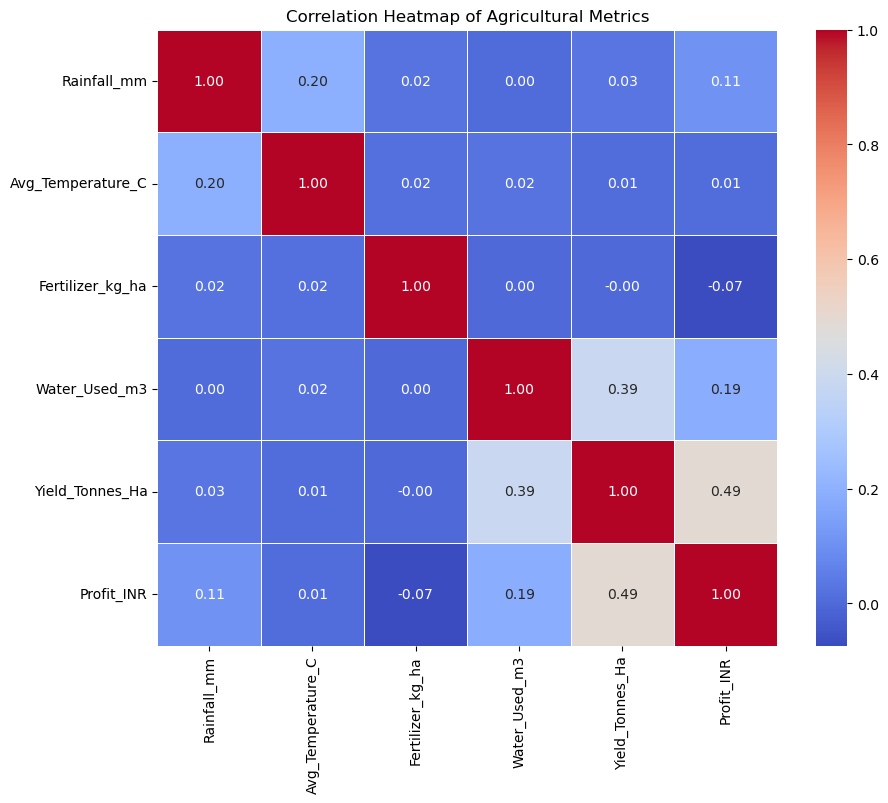

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and clean the data
df = pd.read_csv(r"C:\Users\smrut_koi9iy6\Downloads\seasonal_agriculture_performance_dataset.csv")
cols_to_fill = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']
for col in cols_to_fill:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

# 2. Select key numerical columns to find relationships
numeric_columns = ['Rainfall_mm', 'Avg_Temperature_C', 'Fertilizer_kg_ha', 
                   'Water_Used_m3', 'Yield_Tonnes_Ha', 'Profit_INR']

# 3. Calculate correlation matrix
correlation_matrix = df[numeric_columns].corr()

# 4. Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Agricultural Metrics')
plt.show()

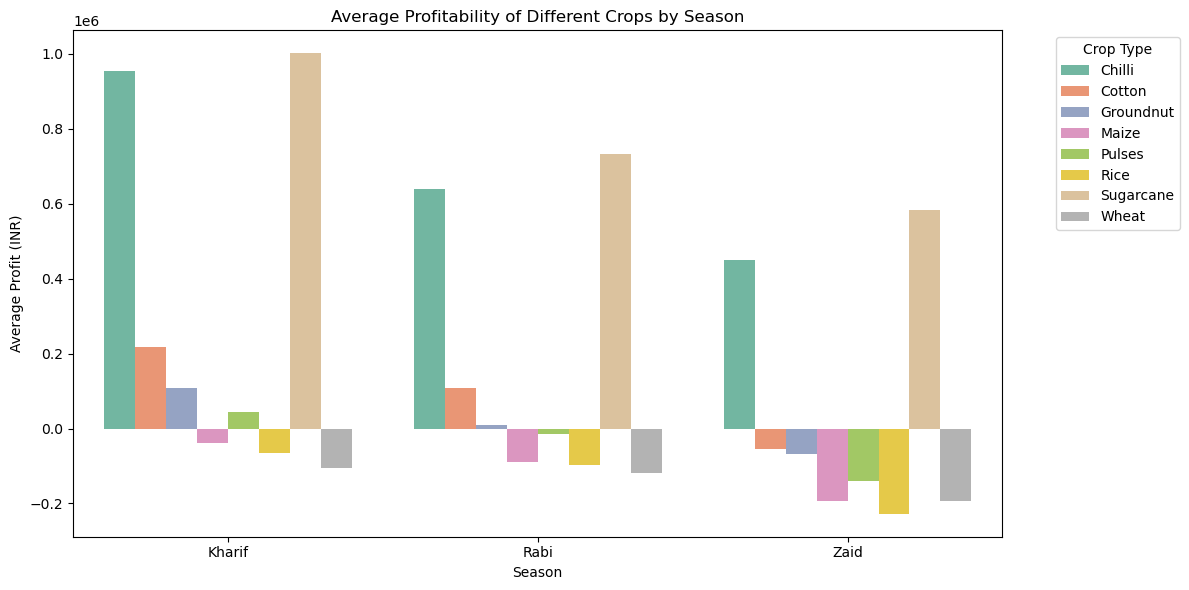

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and clean the data
df = pd.read_csv(r"C:\Users\smrut_koi9iy6\Downloads\seasonal_agriculture_performance_dataset.csv")
df['Yield_Tonnes_Ha'] = df.groupby('Season')['Yield_Tonnes_Ha'].transform(lambda x: x.fillna(x.median()))

# 2. Group data to find average profit per crop for each season
crop_season_profit = df.groupby(['Season', 'Crop'])['Profit_INR'].mean().reset_index()

# 3. Create a clustered bar chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=crop_season_profit, 
    x='Season', 
    y='Profit_INR', 
    hue='Crop', 
    palette='Set2'
)
plt.title('Average Profitability of Different Crops by Season')
plt.ylabel('Average Profit (INR)')
plt.xlabel('Season')
plt.legend(title='Crop Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Adjusts layout so the legend isn't cut off
plt.show()